In [19]:
import numpy as np
import matplotlib.pyplot as plt
import xobjects as xo
import xtrack as xt
import xpart as xp
import xcoll as xc

from matplotlib import colormaps

In [2]:
line = xt.load('../..//injection_lines/sps_with_aperture_inj_q20_beam_sagitta4.json')
env = line.env
tt = line.get_table()
tw = line.twiss()

context = xo.ContextCpu()

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

Done loading line from dict.           


In [3]:
xi_x = 1.5
xi_y = 1.5
qx = 20.13
qy = 20.18
plane = 'DPneg'

num_particles  = 1000
sweep = 6000
sweep = -abs(sweep) if plane == 'DPpos' else abs(sweep)
num_turns = 6000
nemitt_x = 2e-6
nemitt_y = 2e-6
sigma_z = 0.224
sweep_per_turn = sweep/num_turns

In [4]:
#Matching tune and chroma for error variant
env.vars['qph_setvalue'] = xi_x
env.vars['qpv_setvalue'] = xi_y
opt = line.match(
    method='6d', # <- passed to twiss
    vary=[
        xt.VaryList(['kqf0', 'kqd0'], step=1e-8, tag='quad'),
        xt.VaryList(['qph_setvalue', 'qpv_setvalue'], step=1e-4, tag='sext'),
    ],
    targets = [
        xt.TargetSet(qx=qx, qy=qy, tol=1e-6, tag='tune'),
        xt.TargetSet(dqx=xi_x*qx, dqy=xi_y*qy, tol=1e-2, tag='chrom'),
    ])

                                             
Optimize - start penalty: 0.2105                            
Matching: model call n. 7 penalty = 3.9576e-04              
Optimize - end penalty:  0.00039576                            


In [5]:
#Installing TIDP
tidp_ap_tot = 147
block_mvt = 29

line.discard_tracker()
tidp = xc.EverestCollimator(length=4.3, material=xc.materials.Carbon, jaw_L= tidp_ap_tot/2 + block_mvt, jaw_R = -tidp_ap_tot/2 + block_mvt)
line.collimators.install(names=['tidp.11434'], elements=[tidp])

line.build_tracker()

Slicing line:   0%|          | 0/32538 [00:00<?, ?it/s]

In [6]:
#monitors
insertions = []
monitor_names = ['qd.52510', 'qd.61110']
monitors_elems = []
for name in monitor_names:
    monitors_elems.append(xt.ParticlesMonitor(_context=line._context, 
                                                          num_particles=num_particles, 
                                                          start_at_turn=0, 
                                                          stop_at_turn=num_turns+1))
    env.elements[f'{name}_monitor'] = monitors_elems[-1]
    insertions.append(env.place(f'{name}_monitor', at=line.get_s_position(name)))
line.insert(insertions, s_tol=1e-6)

Slicing line:   0%|          | 0/32538 [00:00<?, ?it/s]

In [7]:
#particles
part = xp.generate_matched_gaussian_bunch(nemitt_x=nemitt_x,
                                          nemitt_y=nemitt_y,
                                          sigma_z=sigma_z, num_particles=num_particles, line=line)

*** Maximum RMS bunch length 0.23336637813369315m.
... distance to target bunch length: -2.2228e-01
... distance to target bunch length: 4.5424e-03
... distance to target bunch length: 4.3382e-03
... distance to target bunch length: -6.6565e-03
... distance to target bunch length: 2.0203e-03
... distance to target bunch length: -5.7185e-04
... distance to target bunch length: 1.0779e-04
... distance to target bunch length: 4.7891e-06
... distance to target bunch length: -2.0504e-09
... distance to target bunch length: 9.6490e-08
--> Bunch length: 0.22399999794961262
--> Emittance: 0.34387462232477306


In [8]:
rf_sweep = xc.RFSweep(line)
sweep_per_turn = -abs(sweep_per_turn) if plane == 'DPpos' else abs(sweep_per_turn)
rf_sweep.prepare(sweep_per_turn=sweep_per_turn)
rf_sweep.info()

line.discard_tracker()
line.build_tracker(_context=xo.ContextCpu(omp_num_threads='auto'))
# Track during RF sweep:
line.scattering.enable()
line.track(particles=part, num_turns=num_turns, time=True, with_progress=5)
line.scattering.disable()
print(f"Done sweeping RF in {line.time_last_track:.1f}s.")

Found multiple cavities with different frequencies:
200000000.0Hz  at 4500000.0V: ['actcse.31632']
800000000.0Hz  at 360000.0V: ['acl.31735']
0.0Hz  at 0.0V: ['actcsg.31774' 'actcsj.31958' 'actcsj.31952' 'actcsi.31895'
 'actcsi.31878' 'actcsi.31872' 'actcsh.31854' 'actcsh.31838'
 'actcsh.31832' 'actcsg.31780' 'actcsj.31991' 'actcsg.31758'
 'actcsg.31751' 'actcsf.31695' 'actcsf.31678' 'actcsf.31672'
 'actcse.31654' 'actcse.31637' 'acl.31936' 'actcsj.31974']
The sweep will be performed with respect to the highest voltage cavity at 200000000.0Hz. The other cavities will be shifted accordingly.


Slicing line:   0%|          | 0/32540 [00:00<?, ?it/s]

Enabled time-dependent variables in the line.
The current frequency is 200000001.0Hz, adding 1.0Hz per turn.
This sweep will move the center of the bucket with Δδ = -2.788e-06 per turn.
The bucket height is 0.003652, so this implies the sweep will shift one bucket every 2619.87 turns.
Compiling ContextCpu kernels...


ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored
ld: warning: duplicate -rpath '/Users/lisepauwels/miniforge3/envs/xcoll/lib' ignored


Done compiling ContextCpu kernels.


Tracking:   0%|          | 0/6000 [00:00<?, ?it/s]

Done sweeping RF in 207.5s.


In [75]:
np.unique(env.element_dict['qd.52510_monitor'].x[:,3000][~alive])

array([0.])

Text(0.5, 1.0, 'Phase space at qd.52510_monitor -- Dx = 4.62 m')

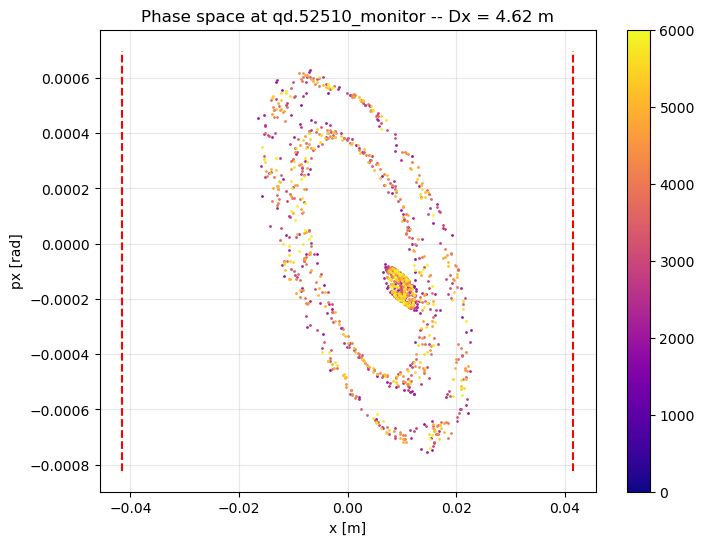

In [80]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
cmap = colormaps['plasma']
norm = plt.Normalize(0, 6000)

for turn in range(1830, 6000, 10):
    alive = env.element_dict['qd.52510_monitor'].state[:,turn]>0
    ax.scatter(env.element_dict['qd.52510_monitor'].x[:,turn][alive], env.element_dict['qd.52510_monitor'].px[:,turn][alive], s=1, color=cmap(norm(turn)))
ymin, ymax = plt.gca().get_ylim()
ax.vlines(-0.0415, ymin, ymax, color='r', linestyle='--')
ax.vlines(0.0415, ymin, ymax, color='r', linestyle='--')
sc = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
ax.grid(alpha=0.3)
ax.set_xlabel('x [m]')
ax.set_ylabel('px [rad]')
ax.set_title(f'Phase space at qd.52510_monitor -- Dx = {tw.rows["qd.52510"].dx[0]:.2f} m')

Text(0.5, 1.0, 'Phase space at qd.52510_monitor -- Dx = 4.62 m')

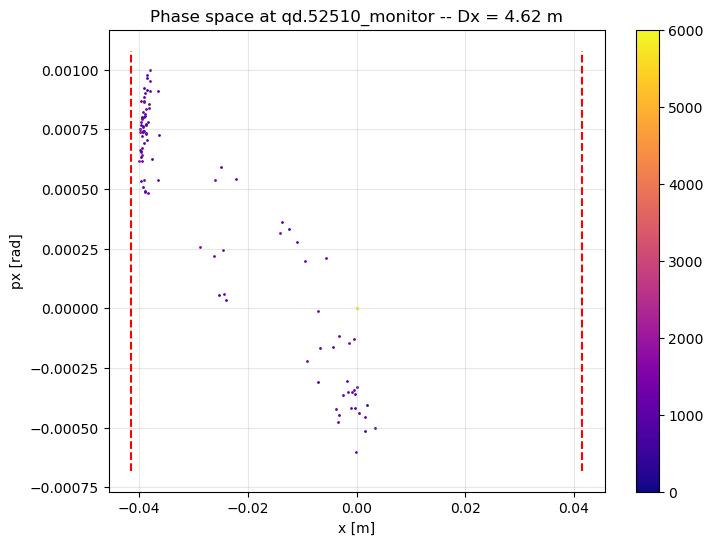

In [77]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
cmap = colormaps['plasma']
norm = plt.Normalize(0, 6000)

for turn in range(1, 6000, 10):
    alive = env.element_dict['qd.52510_monitor'].state[:,turn]>0
    ax.scatter(env.element_dict['qd.52510_monitor'].x[:,turn-1][~alive], env.element_dict['qd.52510_monitor'].px[:,turn-1][~alive], s=1, color=cmap(norm(turn)))
ymin, ymax = plt.gca().get_ylim()
ax.vlines(-0.0415, ymin, ymax, color='r', linestyle='--')
ax.vlines(0.0415, ymin, ymax, color='r', linestyle='--')
sc = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
ax.grid(alpha=0.3)
ax.set_xlabel('x [m]')
ax.set_ylabel('px [rad]')
ax.set_title(f'Phase space at qd.52510_monitor -- Dx = {tw.rows["qd.52510"].dx[0]:.2f} m')

Text(0.5, 1.0, 'Phase space at qd.52510_monitor -- Dy = -0.01 m')

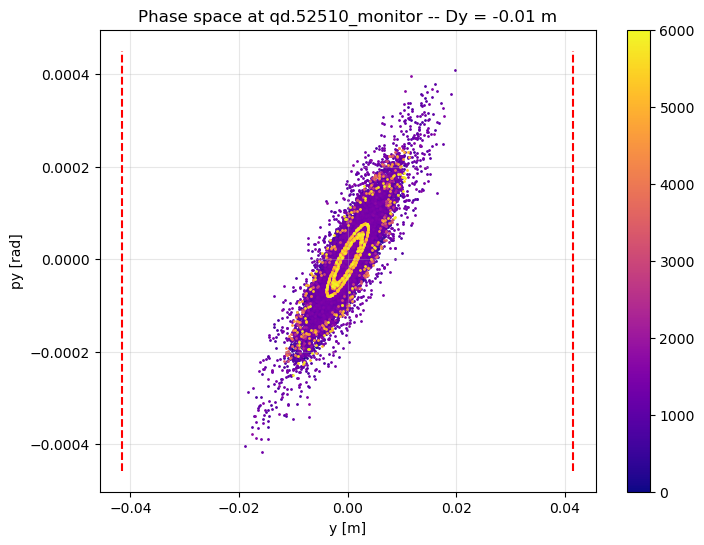

In [67]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
cmap = colormaps['plasma']
norm = plt.Normalize(0, 6000)

for turn in range(0, 6000, 10):
    alive = env.element_dict['qd.52510_monitor'].state[:,turn]>0
    ax.scatter(env.element_dict['qd.52510_monitor'].y[:,turn][alive], env.element_dict['qd.52510_monitor'].py[:,turn][alive], s=1, color=cmap(norm(turn)))
ymin, ymax = plt.gca().get_ylim()
ax.vlines(-0.0415, ymin, ymax, color='r', linestyle='--')
ax.vlines(0.0415, ymin, ymax, color='r', linestyle='--')
sc = plt.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax)
ax.grid(alpha=0.3)
ax.set_xlabel('y [m]')
ax.set_ylabel('py [rad]')
ax.set_title(f'Phase space at qd.52510_monitor -- Dy = {tw.rows["qd.52510"].dy[0]:.2f} m')

In [51]:
idxs, counts = np.unique(part.at_element, return_counts=True)

In [52]:
np.argmax(counts), idxs[np.argmax(counts)], counts[np.argmax(counts)]

(np.int64(16), np.int64(25369), np.int64(439))

In [53]:
line.element_names[idxs[np.argmax(counts)]], line.element_names[idxs[np.argmax(counts)]+1]

('vcak.52501.a_aper', 'drift_1489..2')

In [54]:
env['vcak.52501.a_aper']

View of LimitEllipse(a=0.0415, b=0.0415)

In [57]:
env['veqd.52510.a_aper']

View of LimitEllipse(a=0.0415, b=0.0415)

In [62]:
tt.rows['qd.52510<<40':'qd.52510']

Table: 41 rows, 11 cols
name                            s element_type       isthick isreplica parent_name iscollective ...
mbb.52490..9_aper2        5401.51 LimitRect            False     False None               False
mbb.52490..9              5401.51 ThickSliceRBend       True     False mbb.52490          False
mbb.52490..10_aper2       5402.14 LimitRect            False     False None               False
mbb.52490..exit_map       5402.14 ThinSliceRBendExit   False     False mbb.52490          False
mbb.52490_exit            5402.14 Marker               False     False None               False
drift_1489..0             5402.14 DriftSlice            True     False drift_1489         False
vebb.52490.b_aper         5402.33 LimitRect            False     False None               False
drift_1489..1             5402.33 DriftSlice            True     False drift_1489         False
vcak.52501.a_aper         5402.34 LimitEllipse         False     False None               False
drift_1489..

In [70]:
part.at_element, part.at_turn

(array([    0,     0,     0, 29981,  7956, 19061, 27265, 29315, 19900,
         9244, 14460, 25369,  3706, 19900, 30787, 25369, 25369, 29315,
        25369, 25369, 25369, 25369, 25369, 19900, 25369, 14460, 25369,
        25369, 16347, 25369, 19061, 14460, 19061, 29315, 25369, 14460,
        25369, 25369, 25369, 25369, 25369, 19900, 25369,  9061,  8188,
         3706,  3706, 25369, 14460, 25369, 19900, 25369, 25369, 25369,
        19900, 29981, 25369, 19900, 16347, 25369, 25369, 19900, 25369,
        25369, 25369, 29315, 16347, 25369, 19900, 29315, 29315, 25369,
        29315, 16347, 25369, 16347, 29315,  9061, 16347, 16347, 29315,
        14460, 29299, 29299, 29299, 29315,  3706, 27265,  9061,  3706,
        29299,   126, 29315, 25369, 29315, 29315, 29299, 29299, 29315,
        16347, 25369, 29315, 16347, 29315, 29315, 29299, 29299, 29299,
        29315, 27265,   126, 16347, 29981, 29315, 29299, 29315, 25369,
        29315, 29315, 27265, 29299, 14460, 29299, 29299, 14460, 29315,
      

In [86]:
def delta_to_qx(delta, xi, qx=20.13):
    return xi*qx*delta
def delta_to_qy(delta, xi, qy=20.18):
    return xi*qy*delta

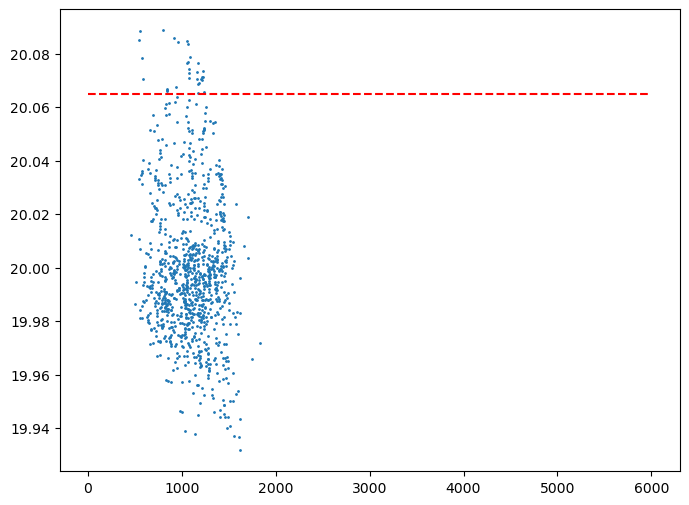

In [92]:
fig, ax = plt.subplots(1,1, figsize=(8,6))

ax.scatter(part.at_turn[3:], delta_to_qx(part.delta[3:], 1.5) + 20.13, s=1)
ax.hlines(20.065, 0,  6000, color='r', linestyle='--')

In [102]:
m, s = np.mean(delta_to_qx(part.delta[3:], 1.5))+ 20.13, np.std(delta_to_qx(part.delta[3:], 1.5))

In [105]:
dead_particles = part.state < 1

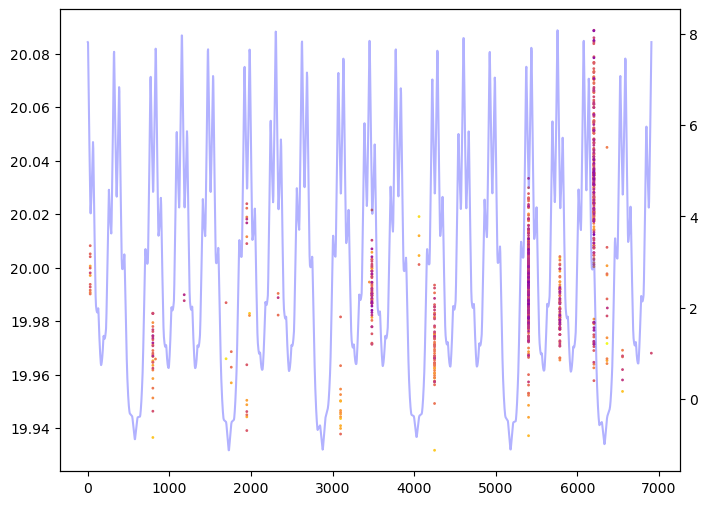

In [129]:
fig, ax = plt.subplots(1,1, figsize=(8,6))
cmap = colormaps['plasma']
norm = plt.Normalize(0, 1830)
ax.scatter(part.s[dead_particles], delta_to_qx(part.delta[dead_particles], 1.5) + 20.13, s=1, c=part.at_turn[dead_particles], cmap=cmap, norm=norm)
ax2 = ax.twinx()
ax2.plot(tw.s, tw.dx, color='blue', alpha=0.3)

In [110]:
np.unique(part.s, return_counts=True)

(array([   0.    ,   29.8516,  797.7962,  829.9007, 1181.9436, 1694.8659,
        1758.8613, 1949.1635, 1981.9293, 1982.51  , 2333.1362, 3098.5008,
        3451.4275, 3482.4735, 4060.1159, 4250.4181, 5402.3354, 5786.3081,
        6202.278 , 6203.6985, 6363.9505, 6367.9603, 6554.2527, 6907.5782]),
 array([  3,  12,  30,   1,   2,   2,   3,  14,   1,   1,   3,  14,   1,
         63,   4,  59, 439,  76, 101, 151,  12,   1,   6,   1]))

In [111]:
np.unique(part.at_element, return_counts=True)

(array([    0,   126,  3706,  3859,  5529,  7956,  8188,  9061,  9227,
         9244, 10949, 14460, 16200, 16347, 19061, 19900, 25369, 27265,
        29299, 29315, 29981, 29985, 30787, 32520]),
 array([  3,  12,  30,   1,   2,   2,   3,  14,   1,   1,   3,  14,   1,
         63,   4,  59, 439,  76, 101, 151,  12,   1,   6,   1]))

In [113]:
line.element_names[29299], line.element_names[29315]

('vttw.61402.a_aper', 'vttw.61402.b_aper')

In [114]:
env.element_dict['vttw.61402.a_aper']

LimitEllipse(a=0.0415, b=0.0415)

In [128]:
tw.rows['vttw.61402.a_aper'].betx, tw.rows['vttw.61402.a_aper'].dx

(array([98.21278732]), array([3.02825064]))

In [127]:
tw.rows['qd.52510'].betx, tw.rows['qd.52510'].dx

(array([32.75459708]), array([4.62308863]))

In [119]:
tw.rows['vttw.61402.a_aper<<10':'vttw.61402.a_aper>>10']

TwissTable: 21 rows, 70 cols
name                             s             x            px             y            py ...
mba.61390..8_aper2         6200.82  -3.97195e-06  -2.76846e-08   4.99237e-07  -2.07262e-08
mba.61390..8               6200.82  -3.97195e-06  -2.76846e-08   4.99237e-07  -2.07262e-08
mba.61390..9_aper2         6201.45  -3.98962e-06  -2.87885e-08   4.86262e-07  -2.07262e-08
mba.61390..9               6201.45  -3.98962e-06  -2.87885e-08   4.86262e-07  -2.07262e-08
mba.61390..10_aper2        6202.07  -4.00799e-06  -2.98923e-08   4.73287e-07  -2.07262e-08
mba.61390..exit_map        6202.07  -4.00799e-06  -2.98923e-08   4.73287e-07  -2.07262e-08
mba.61390_exit             6202.07  -4.00799e-06  -2.99151e-08   4.73287e-07  -2.07289e-08
drift_1699..0              6202.07  -4.00799e-06  -2.99151e-08   4.73287e-07  -2.07289e-08
veba.61390.b_aper          6202.28  -4.01413e-06  -2.99151e-08   4.69032e-07  -2.07289e-08
drift_1699..1              6202.28  -4.01413e-06  -2.9915

In [120]:
env.element_dict['mpsh.61402']

Multipole(order=np.int64(0), inv_factorial_order=1, length=0.714, hxl=0, radiation_flag=np.int64(0), delta_taper=0, knl=[0.], ksl=[0.], isthick=False, num_multipole_kicks=np.int64(0), model='adaptive', integrator='adaptive', shift_x=0, shift_y=0, shift_s=0, rot_s_rad=0, rot_x_rad=0, rot_y_rad=0, rot_s_rad_no_frame=0, rot_shift_anchor=0)

In [134]:
prefixes = []
for nn in tw.rows['vtt.*'].name:
    prefixes.append(nn.split('.')[0])
prefixes = np.unique(prefixes)

In [132]:
env.element_dict['vttb.63602.c_aper']

LimitEllipse(a=0.076, b=0.0192)

In [135]:
prefixes

array(['vttb', 'vttc', 'vttd', 'vtte', 'vttg', 'vttl', 'vttm', 'vtto',
       'vttv', 'vttw', 'vttz'], dtype='<U4')

In [137]:
betxs = []
dxs = []
for nn in tw.rows['vtt.*'].name:
    betxs.append(tw.rows[f'{nn}'].betx[0])
    dxs.append(tw.rows[f'{nn}'].dx[0])

np.unique(dxs, return_counts=True)

(array([-0.62669637, -0.61517171, -0.61312233, -0.54164095, -0.51774317,
        -0.51595798, -0.49421576, -0.49413023, -0.49347178, -0.49347126,
        -0.49298577, -0.4649805 , -0.46481346, -0.46257738, -0.39156626,
        -0.3915071 , -0.39071505, -0.33363396, -0.33280398, -0.32019829,
        -0.30257729, -0.30126097, -0.28208417, -0.2711783 , -0.26980032,
        -0.23724407, -0.23424108, -0.23134849, -0.2306533 , -0.22134687,
         0.63966608,  0.642002  ,  0.64706644,  0.65922255,  0.66597884,
         0.67399378,  0.68236907,  0.69852802,  0.77223306,  0.78372847,
         0.81125316,  0.81293016,  0.82523605,  0.85449652,  0.98530842,
         0.98594286,  0.99041362,  0.99041718,  0.99374855,  1.00029893,
         1.00100374,  1.0059704 ,  1.00597435,  1.00967525,  1.03225439,
         1.03581162,  1.06782302,  1.07102138,  1.07146877,  1.07441571,
         1.07959755,  1.11345655,  1.11619639,  1.11634431,  1.11688749,
         1.15911882,  1.16135559,  1.1621808 ,  1.1

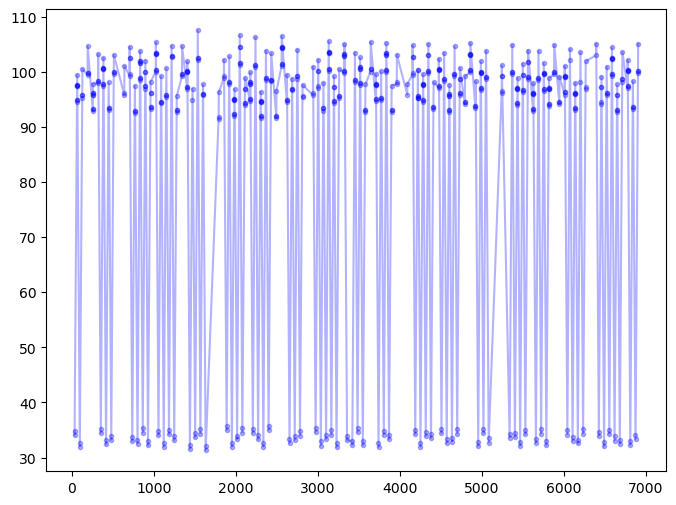

In [142]:
fig, ax = plt.subplots(1,1, figsize=(8,6))
ax.plot(tw.rows['vtt.*'].s, tw.rows['vtt.*'].betx, '.-', color='blue', alpha=0.3)


In [144]:
for pref in prefixes:
    print(tt.rows[f'{pref}.*'].name[0], env.element_dict[tt.rows[f'{pref}.*'].name[0]])

vttb.10402.a_aper LimitEllipse(a=0.078, b=0.078)
vttc.10203.a_aper LimitEllipse(a=0.078, b=0.078)
vttd.11001.a_aper LimitEllipse(a=0.078, b=0.078)
vtte.12205.a_aper LimitEllipse(a=0.076, b=0.0192)
vttg.21005.a_aper LimitEllipse(a=0.078, b=0.078)
vttl.12002.a_aper LimitEllipse(a=0.078, b=0.078)
vttm.12202.a_aper LimitEllipse(a=0.078, b=0.078)
vtto.10105.a_aper LimitEllipse(a=0.0415, b=0.0415)
vttv.10205.a_aper LimitEllipse(a=0.078, b=0.078)
vttw.61402.a_aper LimitEllipse(a=0.0415, b=0.0415)
vttz.31601.a_aper LimitEllipse(a=0.078, b=0.078)


In [146]:
tw.rows['vtto.10105.a_aper'].dx, tw.rows['vtto.10105.a_aper'].betx

(array([4.32217363]), array([34.82797579]))

In [149]:
np.unique(part.at_element, return_counts=True)

(array([    0,   126,  3706,  3859,  5529,  7956,  8188,  9061,  9227,
         9244, 10949, 14460, 16200, 16347, 19061, 19900, 25369, 27265,
        29299, 29315, 29981, 29985, 30787, 32520]),
 array([  3,  12,  30,   1,   2,   2,   3,  14,   1,   1,   3,  14,   1,
         63,   4,  59, 439,  76, 101, 151,  12,   1,   6,   1]))

In [151]:
line.element_names[29315]

'vttw.61402.b_aper'

In [156]:
part.at_turn[(part.at_element==29315) | (part.at_element==29299)]

array([1659, 1581, 1513, 1461, 1455, 1455, 1455, 1452, 1450, 1447, 1445,
       1444, 1443, 1441, 1441, 1438, 1437, 1436, 1436, 1433, 1429, 1427,
       1427, 1427, 1425, 1424, 1424, 1421, 1419, 1419, 1417, 1417, 1413,
       1412, 1412, 1410, 1408, 1406, 1405, 1404, 1402, 1401, 1398, 1392,
       1383, 1379, 1370, 1370, 1369, 1352, 1333, 1332, 1304, 1298, 1291,
       1277, 1277, 1277, 1276, 1275, 1273, 1270, 1262, 1254, 1252, 1250,
       1249, 1243, 1242, 1241, 1239, 1238, 1237, 1236, 1234, 1233, 1228,
       1224, 1223, 1223, 1222, 1221, 1219, 1214, 1212, 1211, 1209, 1203,
       1189, 1183, 1173, 1171, 1171, 1167, 1167, 1163, 1156, 1146, 1139,
       1138, 1137, 1136, 1136, 1136, 1129, 1128, 1124, 1121, 1121, 1119,
       1114, 1109, 1109, 1108, 1108, 1108, 1108, 1106, 1099, 1096, 1096,
       1095, 1094, 1092, 1090, 1089, 1087, 1085, 1081, 1081, 1080, 1080,
       1079, 1079, 1079, 1077, 1077, 1074, 1074, 1074, 1072, 1067, 1066,
       1064, 1059, 1058, 1055, 1054, 1050, 1037, 10

In [ ]:
env.element_dict['vttw.61402.b_aper'].shift_x

AttributeError: 'LimitEllipse' object has no attribute '_shift_x'

In [170]:
from pathlib import Path
import sys
helper_dir = Path("/Users/lisepauwels/sps_simulations/Prototyping/20260113")
sys.path.insert(0, str(helper_dir)) 
from make_aperture import tt_aper
import mplcursors
import scipy.constants as sc

In [167]:
def calculate_bucket_height(line, f_RF=200.26e6, V_RF=3e6):
    # Calculate bucket height
    tw_ref = line.twiss4d()
    beta0 = line.particle_ref.beta0[0]
    E = line.particle_ref.energy0[0]
    q = line.particle_ref.q0
    h = f_RF * line.get_length() / beta0 / sc.c
    eta = tw_ref.slip_factor
    return np.sqrt(2*q*V_RF / (np.pi*h*abs(eta)*E*beta0**2))

def get_twisses(line, bucket_height):
    # Perform a bunch of twisses for different delta0
    tw = {}
    beam_sizes = {}
    nemitt = 2e-6
    for delta in np.linspace(-2*bucket_height, 2*bucket_height, 101):
        this_delta = round(delta,6)
        try:
            tw[this_delta] = line.twiss4d(delta0=delta)
            beam_sizes[this_delta] = tw[this_delta].get_beam_covariance(nemitt_x=nemitt, nemitt_y=nemitt)
        except:
            print(f"Failed for delta0={delta}")
            pass
    return tw, beam_sizes

In [168]:
def plot_momentum_aperture(tw, beam_sizes, bucket_height, figsize=(20, 4), savefig=None, xlim=None, ylim=None, tooltip=False):
    fig, ax = plt.subplots(figsize=figsize)
    delta = list(tw.keys())
    for dd in delta:
        if abs(dd) <= bucket_height + 1.e-12:
            ax.plot(tw[dd].s, tw[dd].x + np.sign(dd)*5*beam_sizes[dd].sigma_x, 'g-')
        else:
            ax.plot(tw[dd].s, tw[dd].x + np.sign(dd)*5*beam_sizes[dd].sigma_x, 'r-')
    line1, = ax.plot(tt_aper.s, tt_aper.aper_max_x, 'k-')
    line2, = ax.plot(tt_aper.s, tt_aper.aper_min_x, 'k-')
    ax.set_xlabel('s [m]')
    ax.set_ylabel('Aperture $x$ [m]')
    ax.set_title(f'Betatron {5}' + r'$\sigma_x$   $\delta$ within 1 bucket (green) and 2 buckets (red)')
    if tooltip:
        cursor = mplcursors.cursor([line1, line2])
        @cursor.connect("add")
        def on_add(sel):
            if hasattr(sel, 'index'):
                raw_idx = sel.index
            else:
                raw_idx = sel.target.index
            idx = int(raw_idx)
            sel.annotation.set_text(tt_aper.name[idx])
    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)
    fig.tight_layout()
    if savefig is not None:
        plt.savefig(savefig, dpi=300)
    plt.show()
    return fig, ax

In [174]:
# line = xt.Line.from_json('../../injection_lines/sps_q20_inj.json')
line = xt.load('../..//injection_lines/sps_with_aperture_inj_q20_beam_sagitta4.json')
tt = line.get_table()
tw = line.twiss()
env = line.env
cavity_elements, cavity_names = line.get_elements_of_type(xt.Cavity)
for name in cavity_names:
    line[name].frequency = 200e6
    line[name].lag = 180
    line[name].voltage = 0
line['acl.31735'].voltage = 0 #setting 800 cav to 0V
line['actcse.31632'].voltage = 3.0e6


env.vars['qph_setvalue'] = 1.5
env.vars['qpv_setvalue'] = 1.5
qx = 20.13
qy = 20.18
opt = line.match(
    method='6d', # <- passed to twiss
    vary=[
        xt.VaryList(['kqf0', 'kqd0'], step=1e-8, tag='quad'),
        xt.VaryList(['qph_setvalue', 'qpv_setvalue'], step=1e-4, tag='sext'),
    ],
    targets = [
        xt.TargetSet(qx=qx, qy=qy, tol=1e-6, tag='tune'),
        xt.TargetSet(dqx=0.5*qx, dqy=0.5*qy, tol=1e-2, tag='chrom'),
    ])

tw_lin, beam_sizes_lin = get_twisses(line, calculate_bucket_height(line, V_RF=3e6))

Loading line from dict:   0%|          | 0/36381 [00:00<?, ?it/s]

Done loading line from dict.           
                                             
Optimize - start penalty: 28.63                             
Matching: model call n. 13 penalty = 3.1623e-05              
Optimize - end penalty:  3.16233e-05                            


In [185]:
tt.rows['vttw.61402.a_aper<<200':'vttw.61402.b_aper>>200'].show()

name                              s element_type            isthick isreplica parent_name        ...
mbb.61270..exit_map         6163.44 ThinSliceRBendExit        False     False mbb.61270         
mbb.61270_exit              6163.44 Marker                    False     False None              
drift_1688..0               6163.44 DriftSlice                 True     False drift_1688        
vebb.61270.b_aper           6163.64 LimitRect                 False     False None              
drift_1688..1               6163.64 DriftSlice                 True     False drift_1688        
vebb.61290.a_aper           6163.64 LimitRect                 False     False None              
drift_1688..2               6163.64 DriftSlice                 True     False drift_1688        
mbb.61290_entry             6163.82 Marker                    False     False None              
mbb.61290..entry_map        6163.82 ThinSliceRBendEntry       False     False mbb.61290         
mbb.61290..0_aper2        

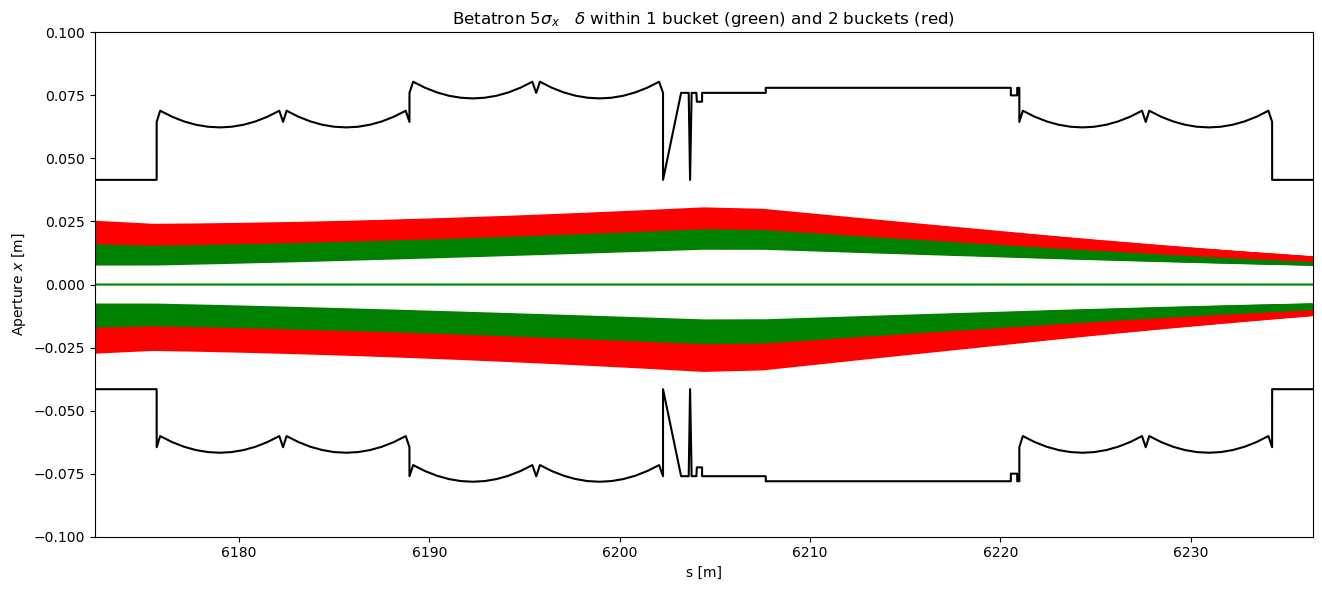

(<Figure size 1333x600 with 1 Axes>,
 <Axes: title={'center': 'Betatron 5$\\sigma_x$   $\\delta$ within 1 bucket (green) and 2 buckets (red)'}, xlabel='s [m]', ylabel='Aperture $x$ [m]'>)

In [187]:
plot_momentum_aperture(tw_lin, beam_sizes_lin, calculate_bucket_height(line, V_RF=3e6), figsize=(13.33, 6), 
                       xlim=(tw.rows['qd.61310'].s, tw.rows['qd.61510'].s), ylim=(-0.1,0.1))
# plot_momentum_aperture(tw_lin, beam_sizes_lin, calculate_bucket_height(line, V_RF=3e6), figsize=(13.33, 6), 
#                        xlim=(tw.rows['qf.52210'].s, tw.rows['qf.52810'].s), ylim=(-0.1,0.1))

In [191]:
np.mean(part.x[(part.at_element==29315) | (part.at_element==29299)]), np.std(part.x[(part.at_element==29315) | (part.at_element==29299)])

(np.float64(-0.041988552625895646), np.float64(0.0005750133505624628))

In [192]:
np.mean(part.y[(part.at_element==29315) | (part.at_element==29299)]), np.std(part.y[(part.at_element==29315) | (part.at_element==29299)])

(np.float64(-8.075427654011845e-05), np.float64(0.0028979268713581296))

We lose on aperture in x in vttw. But in fact, it should be a vttb, which is much larger. What is the loss mechanism? Dispersion ? To be checked...